# Temperature-Broadened Rabi Flop vs Pulse Duration

This notebook simulates a single pulse with variable duration and plots the ensemble-averaged Rabi flop over many `pi` pulse areas.

Velocities are sampled from a 1D Maxwell-Boltzmann distribution, matching the temperature treatment in `mach_zehnder_with_temperature.ipynb`.

In [1]:
import sys

import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from tqdm import tqdm
# from tqdm.notebook import tqdm

import sys
sys.path.insert(0, '..')

import lmt_sim.version_info as vs
from lmt_sim.lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
)

%matplotlib inline

In [3]:
# np.random.seed(42)

T_PI = 45e-6
RABI_FREQ = 1.0 / (2.0 * T_PI)

MASS_ATOM = constants.atomic_mass * 87.0
TRANSITION_WAVELENGTH = 698e-9

TEMPERATURE = 200e-9
N_ATOMS = 300

N_DURATION_POINTS = 300
MAX_AREA_PI = 20.0

# Single-photon recoil frequency
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)
BASE_DETUNING_HZ = F_RECOIL / 2  # Same detuning as MZ


In [4]:
sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0.0, sigma_v, size=N_ATOMS)
pulse_durations = np.linspace(0.0, MAX_AREA_PI * T_PI, N_DURATION_POINTS)
pulse_area_over_pi = pulse_durations / T_PI

print(f"sigma_v = {sigma_v:.3e} m/s")
print(f"Max pulse duration = {pulse_durations[-1] * 1e6:.1f} us ({MAX_AREA_PI:.1f} pi area)")

sigma_v = 4.372e-03 m/s
Max pulse duration = 900.0 us (20.0 pi area)


In [5]:
def calc_single_pulse_excitation_borde(
    pulse_duration,
    detuning_hz=0.0,
    initial_velocity_z=0.0,
):
    state = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2.0 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=0.0,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    state = pulse_interaction_in_borde_representation(
        state,
        pulse_detuning=detuning_hz,
        t_pulse=pulse_duration,
        pulse_rabi_freq=RABI_FREQ,
        pulse_phase=0.0,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=pulse_duration,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob, excited_prob = calculate_ground_and_excited_probabilities(state)

    total_prob = ground_prob + excited_prob
    return excited_prob / total_prob


In [6]:
excitation_traces = np.empty((N_ATOMS, N_DURATION_POINTS))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    for ind_duration, pulse_duration in enumerate(pulse_durations):
        excitation_traces[ind_atom, ind_duration] = calc_single_pulse_excitation_borde(
            pulse_duration=pulse_duration,
            detuning_hz=BASE_DETUNING_HZ,
            initial_velocity_z=velocity,
        )

mean_excitation = np.mean(excitation_traces, axis=0)
std_excitation = np.std(excitation_traces, axis=0)

ideal_excitation = np.array([
    calc_single_pulse_excitation_borde(
        pulse_duration=pulse_duration,
        detuning_hz=BASE_DETUNING_HZ,
        initial_velocity_z=0.0,
    )
    for pulse_duration in pulse_durations
])

Simulating atoms:   0%|                                                                         | 0/300 [00:00<?, ?it/s]

Simulating atoms:   1%|▍                                                                | 2/300 [00:00<00:18, 16.22it/s]

Simulating atoms:   1%|▊                                                                | 4/300 [00:00<00:17, 16.94it/s]

Simulating atoms:   2%|█▎                                                               | 6/300 [00:00<00:16, 17.75it/s]

Simulating atoms:   3%|█▋                                                               | 8/300 [00:00<00:17, 16.53it/s]

...

Simulating atoms:  98%|█████████████████████████████████████████████████████████████▋ | 294/300 [00:17<00:00, 17.14it/s]

Simulating atoms:  99%|██████████████████████████████████████████████████████████████▏| 296/300 [00:17<00:00, 17.62it/s]

Simulating atoms:  99%|██████████████████████████████████████████████████████████████▌| 298/300 [00:17<00:00, 17.06it/s]

Simulating atoms: 100%|███████████████████████████████████████████████████████████████| 300/300 [00:17<00:00, 16.87it/s]

Simulating atoms: 100%|███████████████████████████████████████████████████████████████| 300/300 [00:17<00:00, 17.03it/s]

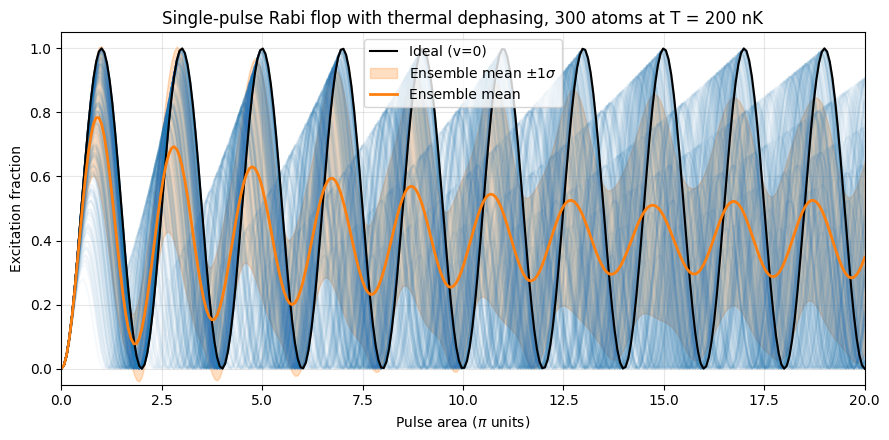

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for trace in excitation_traces:
    ax.plot(pulse_area_over_pi, trace, color="tab:blue", alpha=0.04)

ax.plot(pulse_area_over_pi, ideal_excitation, color="black", lw=1.5, label="Ideal (v=0)")
ax.fill_between(
    pulse_area_over_pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.25,
    label=r"Ensemble mean $\pm 1\sigma$",
)
ax.plot(pulse_area_over_pi, mean_excitation, color="tab:orange", lw=2.0, label="Ensemble mean")

ax.set_xlabel(r"Pulse area ($\pi$ units)")
ax.set_ylabel("Excitation fraction")
ax.set_xlim(0, MAX_AREA_PI)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(
    rf"Single-pulse Rabi flop with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE * 1e9:.0f} nK"
)
fig.tight_layout()
vs.tag_plot(small=True)